In [2]:
# =========================
# IMPORTS
# =========================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix,
    classification_report
)

In [3]:
# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# =========================
# PATHS (YOUR DATASET)
# =========================
DATASET_PATH = r"D:\Datasets\Phase1_224x224_RGB"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_seen_dir = os.path.join(DATASET_PATH, "test_seen")
test_unseen_dir = os.path.join(DATASET_PATH, "test_unseen")


In [5]:
# =========================
# TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
# =========================
# DATASETS
# =========================
BATCH_SIZE = 8   # safe for RTX 3050 (change to 4 if OOM)

train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds = datasets.ImageFolder(val_dir, transform=val_transform)
test_seen_ds = datasets.ImageFolder(test_seen_dir, transform=val_transform)
test_unseen_ds = datasets.ImageFolder(test_unseen_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_seen_loader = DataLoader(test_seen_ds, batch_size=BATCH_SIZE, shuffle=False)
test_unseen_loader = DataLoader(test_unseen_ds, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
# =========================
# MODEL - DENSENET121
# =========================
model = models.densenet121(weights="DEFAULT")
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

In [8]:
# =========================
# LOSS + OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [9]:
# AMP (NEW API)
scaler = torch.amp.GradScaler("cuda")


In [10]:
# =========================
# TRAINING SETTINGS
# =========================
EPOCHS = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0

In [11]:
# =========================
# TRAIN LOOP
# =========================
for epoch in range(EPOCHS):

    model.train()
    running_loss, correct = 0, 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_ds)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

In [12]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [14]:
# =========================
# TRAIN LOOP
# =========================
torch.backends.cudnn.benchmark = True
for epoch in range(EPOCHS):

    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    running_loss, correct = 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

        # OPTIONAL: show batch progress
        if (batch_idx + 1) % 20 == 0:
            print(f"Batch [{batch_idx+1}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_ds)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    # ===== VALIDATION =====
    model.eval()
    vloss, vcorrect = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            vloss += loss.item()
            preds = outputs.argmax(1)
            vcorrect += (preds == labels).sum().item()

    val_loss = vloss / len(val_loader)
    val_acc = vcorrect / len(val_ds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {val_acc:.4f}")

    # SAVE BEST MODEL
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_densenet121.pth")


===== Epoch 1/15 =====
Batch [20/1000] Loss: 0.0001
Batch [40/1000] Loss: 0.0012
Batch [60/1000] Loss: 0.0008
Batch [80/1000] Loss: 0.0000
Batch [100/1000] Loss: 0.0000
Batch [120/1000] Loss: 0.0000
Batch [140/1000] Loss: 0.0001
Batch [160/1000] Loss: 0.0000
Batch [180/1000] Loss: 0.0001
Batch [200/1000] Loss: 0.0001
Batch [220/1000] Loss: 0.0000
Batch [240/1000] Loss: 0.0000
Batch [260/1000] Loss: 0.0001
Batch [280/1000] Loss: 0.0003
Batch [300/1000] Loss: 0.0000
Batch [320/1000] Loss: 0.0005
Batch [340/1000] Loss: 0.0008
Batch [360/1000] Loss: 0.0000
Batch [380/1000] Loss: 0.0000
Batch [400/1000] Loss: 0.0000
Batch [420/1000] Loss: 0.0000
Batch [440/1000] Loss: 0.0001
Batch [460/1000] Loss: 0.0000
Batch [480/1000] Loss: 0.0000
Batch [500/1000] Loss: 0.0021
Batch [520/1000] Loss: 0.0551
Batch [540/1000] Loss: 0.0003
Batch [560/1000] Loss: 0.0000
Batch [580/1000] Loss: 0.0002
Batch [600/1000] Loss: 0.0001
Batch [620/1000] Loss: 0.0001
Batch [640/1000] Loss: 0.0001
Batch [660/1000] Los

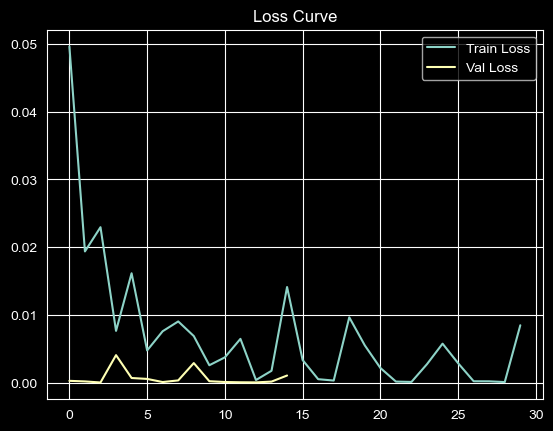

In [15]:
# =========================
# CURVES
# =========================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [23]:
def evaluate(model, loader, return_preds=False):

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:,1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels, all_probs

    return avg_loss, accuracy

In [24]:
# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load("best_densenet121.pth"))

C:\Users\harsh\AppData\Local\Temp\ipykernel_5908\2538634190.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_densenet121.pth"))


<All keys matched successfully>

In [25]:
# =========================
# TEST EVALUATION
# =========================
evaluate(test_seen_loader, "TEST SEEN")
evaluate(test_unseen_loader, "TEST UNSEEN")

AttributeError: 'DataLoader' object has no attribute 'eval'

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [27]:
def plot_roc(labels, probs, name):

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    return roc_auc


===== FINAL RESULTS =====
Train Acc:       1.0000
Validation Acc:  1.0000
Test Seen Acc:   1.0000
Test Unseen Acc: 0.9667


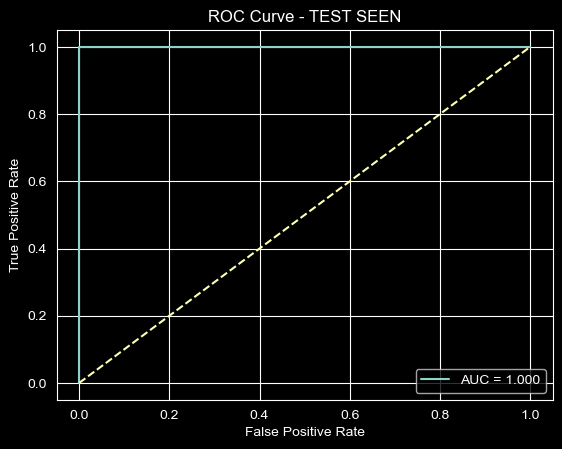

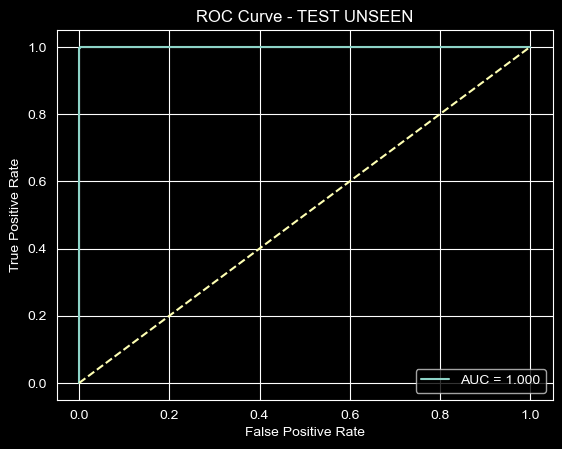


AUC Seen:   1.0000
AUC Unseen: 1.0000

Confusion Matrix - Test Seen
[[500   0]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix - Test Unseen
[[950  50]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1000
           1       0.91      1.00      0.95       500

    accuracy                           0.97      1500
   macro avg       0.95      0.97      0.96      1500
weighted avg       0.97      0.97      0.97      1500



In [28]:
# ===============================
# FINAL EVALUATION
# ===============================

train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels, seen_probs = evaluate(
    model, test_seen_loader, True
)

test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, True
)

print("\n===== FINAL RESULTS =====")
print(f"Train Acc:       {train_acc:.4f}")
print(f"Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Acc: {test_unseen_acc:.4f}")

# ===== ROC + AUC =====
seen_auc = plot_roc(seen_labels, seen_probs, "TEST SEEN")
unseen_auc = plot_roc(unseen_labels, unseen_probs, "TEST UNSEEN")

print(f"\nAUC Seen:   {seen_auc:.4f}")
print(f"AUC Unseen: {unseen_auc:.4f}")

# ===== CONFUSION MATRIX =====
print("\nConfusion Matrix - Test Seen")
print(confusion_matrix(seen_labels, seen_preds))
print(classification_report(seen_labels, seen_preds))

print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))